<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Questao2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

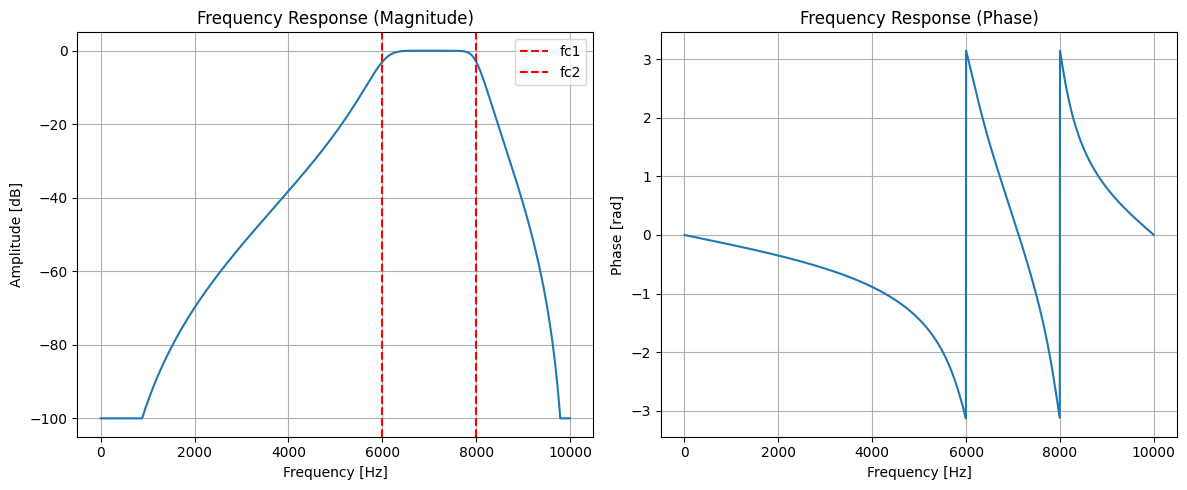

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Filter specifications
fs = 20000
fc1 = 6000
fc2 = 8000
order = 4  # Total order (2 blocks of 2nd order)

# Design the filter using SOS (Second-Order Sections)
sos = signal.butter(order, [fc1, fc2], btype='bandpass', fs=fs, output='sos')

# 1. Frequency Response
w, h = signal.sosfreqz(sos, worN=2000, fs=fs)

plt.figure(figsize=(12, 5))

# Magnitude Plot
plt.subplot(1, 2, 1)
plt.plot(w, 20 * np.log10(np.maximum(abs(h), 1e-5)))
plt.title('Frequency Response (Magnitude)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.axvline(fc1, color='red', linestyle='--', label='fc1')
plt.axvline(fc2, color='red', linestyle='--', label='fc2')
plt.grid(True)
plt.legend()

# Phase Plot
plt.subplot(1, 2, 2)
plt.plot(w, np.angle(h))
plt.title('Frequency Response (Phase)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [rad]')
plt.grid(True)

plt.tight_layout()
plt.show()

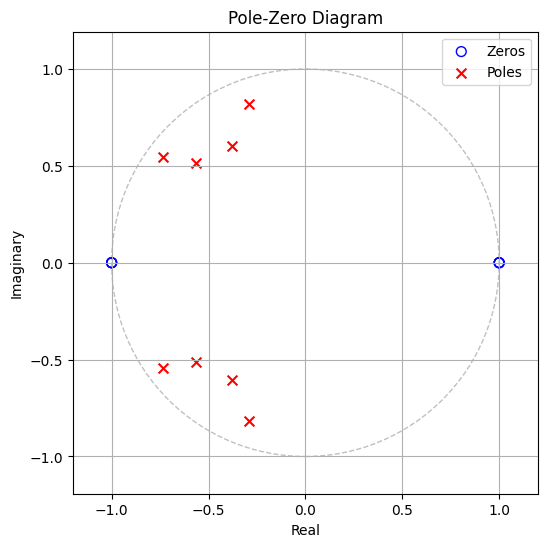

In [2]:
def plot_pole_zero_sos(sos):
    """Helper to plot poles and zeros from SOS format."""
    plt.figure(figsize=(6, 6))
    z, p, k = signal.sos2zpk(sos)

    # Plot Unit Circle
    unit_circle = plt.Circle((0, 0), 1, color='silver', fill=False, linestyle='--')
    plt.gca().add_artist(unit_circle)

    # Plot Zeros and Poles
    plt.scatter(np.real(z), np.imag(z), s=50, marker='o', facecolors='none', edgecolors='blue', label='Zeros')
    plt.scatter(np.real(p), np.imag(p), s=50, marker='x', color='red', label='Poles')

    plt.title('Pole-Zero Diagram')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.xlim([-1.2, 1.2])
    plt.ylim([-1.2, 1.2])
    plt.show()

plot_pole_zero_sos(sos)

### Análise dos Resultados

1. **Cascata de 2ª Ordem (SOS):** O uso de estruturas `sos` (Second-Order Sections) é fundamental para filtros de ordem elevada ou banda estreita, pois minimiza erros de quantização e instabilidade numérica comparado à forma direta (coeficientes `b, a`).
2. **Resposta em Frequência:** O gráfico mostra uma banda de passagem centrada entre 6000 Hz e 8000 Hz. Com a ordem 4, observamos uma transição definida, embora a inclinação dependa da ordem escolhida para os blocos básicos.
3. **Polos e Zeros:** Os polos estão localizados dentro do círculo unitário, garantindo estabilidade. Para um filtro passa-faixas, os zeros geralmente se concentram em $z=1$ (frequência 0) e $z=-1$ (frequência de Nyquist).
4. **Comparação:** Comparado a um filtro projetado em forma direta, a cascata de 2ª ordem mantém a fidelidade da resposta em frequência mesmo se aumentarmos a seletividade, evitando o deslocamento de polos devido à precisão finita.